<a href="https://colab.research.google.com/github/sorotdaniel/portfolio-soro/blob/main/seances8_9(Nettoyage).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

# Données de gestion des incidents

# description des données: https://archive.ics.uci.edu/dataset/498/incident+management+process+enriched+event+log


In [ ]:
df = pd.read_csv('/content/incident_event_log.csv', sep=',')

In [ ]:
df

,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,...,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,29/2/2016 04:40,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141707,INC0120835,Closed,False,1,0,4,True,Caller 116,Opened by 12,16/2/2017 09:09,...,True,Do Not Notify,?,?,?,?,code 9,Resolved by 9,16/2/2017 09:53,16/2/2017 09:53
141708,INC0121064,Active,True,0,0,0,True,Caller 116,Opened by 12,16/2/2017 14:17,...,False,Do Not Notify,?,?,?,?,code 6,Resolved by 9,16/2/2017 16:38,16/2/2017 16:38
141709,INC0121064,Active,True,1,0,1,True,Caller 116,Opened by 12,16/2/2017 14:17,...,False,Do Not Notify,?,?,?,?,code 6,Resolved by 9,16/2/2017 16:38,16/2/2017 16:38
141710,INC0121064,Resolved,True,1,0,2,True,Caller 116,Opened by 12,16/2/2017 14:17,...,True,Do Not Notify,?,?,?,?,code 6,Resolved by 9,16/2/2017 16:38,16/2/2017 16:38


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141712 entries, 0 to 141711
Data columns (total 36 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   number                   141712 non-null  object
 1   incident_state           141712 non-null  object
 2   active                   141712 non-null  bool  
 3   reassignment_count       141712 non-null  int64 
 4   reopen_count             141712 non-null  int64 
 5   sys_mod_count            141712 non-null  int64 
 6   made_sla                 141712 non-null  bool  
 7   caller_id                141712 non-null  object
 8   opened_by                141712 non-null  object
 9   opened_at                141712 non-null  object
 10  sys_created_by           141712 non-null  object
 11  sys_created_at           141712 non-null  object
 12  sys_updated_by           141712 non-null  object
 13  sys_updated_at           141712 non-null  object
 14  contact_type        

In [ ]:
df.problem_id.value_counts()

,count
problem_id,
?,139417
Problem ID 14,184
Problem ID 2,147
Problem ID 52,82
Problem ID 239,48
...,...
Problem ID 11,1
Problem ID 88,1
Problem ID 33,1


In [ ]:
result = df[df['problem_id'] == '?']  #iloc[10000:10050]

result

,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,...,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,29/2/2016 04:40,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141707,INC0120835,Closed,False,1,0,4,True,Caller 116,Opened by 12,16/2/2017 09:09,...,True,Do Not Notify,?,?,?,?,code 9,Resolved by 9,16/2/2017 09:53,16/2/2017 09:53
141708,INC0121064,Active,True,0,0,0,True,Caller 116,Opened by 12,16/2/2017 14:17,...,False,Do Not Notify,?,?,?,?,code 6,Resolved by 9,16/2/2017 16:38,16/2/2017 16:38
141709,INC0121064,Active,True,1,0,1,True,Caller 116,Opened by 12,16/2/2017 14:17,...,False,Do Not Notify,?,?,?,?,code 6,Resolved by 9,16/2/2017 16:38,16/2/2017 16:38
141710,INC0121064,Resolved,True,1,0,2,True,Caller 116,Opened by 12,16/2/2017 14:17,...,True,Do Not Notify,?,?,?,?,code 6,Resolved by 9,16/2/2017 16:38,16/2/2017 16:38


In [ ]:
df.rfc.value_counts()

,count
rfc,
?,140721
CHG0000132,20
CHG0001230,20
CHG0000047,18
CHG0001656,17
...,...
CHG0003305,2
CHG0001829,1
CHG0000530,1


# On remplace les "?" par les NA

In [ ]:
df = pd.read_csv('/content/incident_event_log.csv', na_values=["?"], sep=',')

/tmp/ipython-input-3349603106.py:1: DtypeWarning: Columns (19,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/incident_event_log.csv', na_values=["?"], sep=',')


In [ ]:
df.head(25)

,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,...,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,29/2/2016 04:40,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00
5,INC0000047,Active,True,1,0,1,True,Caller 2403,Opened by 397,29/2/2016 04:40,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00
6,INC0000047,Active,True,1,0,2,True,Caller 2403,Opened by 397,29/2/2016 04:40,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00
7,INC0000047,Active,True,1,0,3,True,Caller 2403,Opened by 397,29/2/2016 04:40,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00
8,INC0000047,Active,True,1,0,4,True,Caller 2403,Opened by 397,29/2/2016 04:40,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00
9,INC0000047,Active,True,1,0,5,True,Caller 2403,Opened by 397,29/2/2016 04:40,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141712 entries, 0 to 141711
Data columns (total 36 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   number                   141712 non-null  object
 1   incident_state           141712 non-null  object
 2   active                   141712 non-null  bool  
 3   reassignment_count       141712 non-null  int64 
 4   reopen_count             141712 non-null  int64 
 5   sys_mod_count            141712 non-null  int64 
 6   made_sla                 141712 non-null  bool  
 7   caller_id                141683 non-null  object
 8   opened_by                136877 non-null  object
 9   opened_at                141712 non-null  object
 10  sys_created_by           88636 non-null   object
 11  sys_created_at           88636 non-null   object
 12  sys_updated_by           141712 non-null  object
 13  sys_updated_at           141712 non-null  object
 14  contact_type        

# 0- Verification de la cohérence

In [ ]:
print(df.columns.tolist()) # on affiche ici la liste des colonnes de notre dataset


['number', 'incident_state', 'active', 'reassignment_count', 'reopen_count', 'sys_mod_count', 'made_sla', 'caller_id', 'opened_by', 'opened_at', 'sys_created_by', 'sys_created_at', 'sys_updated_by', 'sys_updated_at', 'contact_type', 'location', 'category', 'subcategory', 'u_symptom', 'cmdb_ci', 'impact', 'urgency', 'priority', 'assignment_group', 'assigned_to', 'knowledge', 'u_priority_confirmation', 'notify', 'problem_id', 'rfc', 'vendor', 'caused_by', 'closed_code', 'resolved_by', 'resolved_at', 'closed_at']


In [ ]:

cols_wanted = ['opened_at','resolved_at','closed_at','sys_created_at','sys_updated_at']
cols_present = [c for c in cols_wanted if c in df.columns]

for col in cols_present:
    df[col] = pd.to_datetime(df[col], format="%d/%m/%Y %H:%M", errors='coerce')  # si format connu
    # ou si format variable :
    # df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')
    n_bad = df[col].isna().sum()
    print(f"{col}: convertie, valeurs manquantes après conversion = {n_bad}")


opened_at: convertie, valeurs manquantes après conversion = 0
resolved_at: convertie, valeurs manquantes après conversion = 3141
closed_at: convertie, valeurs manquantes après conversion = 0
sys_created_at: convertie, valeurs manquantes après conversion = 53076
sys_updated_at: convertie, valeurs manquantes après conversion = 0


In [ ]:
df

,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,...,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 149,2016-02-29 11:29:00,2016-03-05 12:00:00
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 149,2016-02-29 11:29:00,2016-03-05 12:00:00
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 149,2016-02-29 11:29:00,2016-03-05 12:00:00
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 149,2016-02-29 11:29:00,2016-03-05 12:00:00
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,2016-02-29 04:40:00,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 81,2016-03-01 09:52:00,2016-03-06 10:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141707,INC0120835,Closed,False,1,0,4,True,Caller 116,Opened by 12,2017-02-16 09:09:00,...,True,Do Not Notify,NaN,NaN,NaN,NaN,code 9,Resolved by 9,2017-02-16 09:53:00,2017-02-16 09:53:00
141708,INC0121064,Active,True,0,0,0,True,Caller 116,Opened by 12,2017-02-16 14:17:00,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 6,Resolved by 9,2017-02-16 16:38:00,2017-02-16 16:38:00
141709,INC0121064,Active,True,1,0,1,True,Caller 116,Opened by 12,2017-02-16 14:17:00,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 6,Resolved by 9,2017-02-16 16:38:00,2017-02-16 16:38:00
141710,INC0121064,Resolved,True,1,0,2,True,Caller 116,Opened by 12,2017-02-16 14:17:00,...,True,Do Not Notify,NaN,NaN,NaN,NaN,code 6,Resolved by 9,2017-02-16 16:38:00,2017-02-16 16:38:00


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141712 entries, 0 to 141711
Data columns (total 36 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   number                   141712 non-null  object        
 1   incident_state           141712 non-null  object        
 2   active                   141712 non-null  bool          
 3   reassignment_count       141712 non-null  int64         
 4   reopen_count             141712 non-null  int64         
 5   sys_mod_count            141712 non-null  int64         
 6   made_sla                 141712 non-null  bool          
 7   caller_id                141683 non-null  object        
 8   opened_by                136877 non-null  object        
 9   opened_at                141712 non-null  datetime64[ns]
 10  sys_created_by           88636 non-null   object        
 11  sys_created_at           88636 non-null   datetime64[ns]
 12  sys_updated_by  

In [ ]:
# Vérification de la cohérence
print("  COHÉRENCE DES DONNÉES")
print("=" * 50)
# Vérification des formats de dates

date_columns = df.select_dtypes(include=['datetime64']).columns
print('Les colonnes de type date:',date_columns)
for col in date_columns:
    future_dates = df[col] > pd.Timestamp.now()
    print(f"Dates futures dans {col}: {future_dates.sum()}")
# Vérification des plages de valeurs
if 'age' in df.columns:
    invalid_ages = (df['age'] < 0) | (df['age'] > 120)
    print(f"Âges invalides: {invalid_ages.sum()}")
else:
    print("Aucune colonne de date ou d'âge  incorrecte trouvée.")

  COHÉRENCE DES DONNÉES
Les colonnes de type date: Index(['opened_at', 'sys_created_at', 'sys_updated_at', 'resolved_at',
       'closed_at'],
      dtype='object')
Dates futures dans opened_at: 0
Dates futures dans sys_created_at: 0
Dates futures dans sys_updated_at: 0
Dates futures dans resolved_at: 0
Dates futures dans closed_at: 0
Aucune colonne de date ou d'âge  incorrecte trouvée.


# 1-verification des doublons

In [ ]:
# Analyse des doublons
print("DOUBLONS")
print("=" * 50)

# Doublons complets
complete_duplicates = df.duplicated().sum()
print(f"Doublons complets : {complete_duplicates}")

# Doublons sur la colonne 'id' (si elle existe)
if 'id' in df.columns:
    id_duplicates = df.duplicated(subset=['id']).sum()
    print(f"Doublons d'ID : {id_duplicates}")

# Affichage des doublons (exemples)
if complete_duplicates > 0:
    print("\nExemples de doublons :")
    duplicate_rows = df[df.duplicated(keep=False)]
    print(duplicate_rows.head())


DOUBLONS
Doublons complets : 0


# 2-Detection des valeurs aberrantes

In [ ]:
#Détection des valeurs aberrantes par intervalle inter-quartile
print("  VALEURS ABERRANTES   ")
print("=" * 50)

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

# Application sur les colonnes numériques
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    outliers = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} valeurs aberrantes")

  VALEURS ABERRANTES   
reassignment_count: 19635 valeurs aberrantes
reopen_count: 2314 valeurs aberrantes
sys_mod_count: 10900 valeurs aberrantes


# 3-Valeurs Manquantes

In [ ]:
# Analyse des valeurs manquantes
print("   VALEURS MANQUANTES   ")
print("=" * 50)
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df))*100
missing_df = pd.DataFrame({
    'Valeurs_manquantes': missing_data,
    'Pourcentage': missing_percent})
print("Valeurs manquantes par colonne:")
print(missing_df[missing_df['Valeurs_manquantes'] > 0]
      .sort_values('Pourcentage', ascending=False))


   VALEURS MANQUANTES   
Valeurs manquantes par colonne:
                  Valeurs_manquantes  Pourcentage
caused_by                     141689    99.983770
vendor                        141468    99.827820
cmdb_ci                       141267    99.685983
rfc                           140721    99.300694
problem_id                    139417    98.380518
sys_created_by                 53076    37.453427
sys_created_at                 53076    37.453427
u_symptom                      32964    23.261262
assigned_to                    27496    19.402732
assignment_group               14213    10.029496
opened_by                       4835     3.411849
resolved_at                     3141     2.216467
closed_code                      714     0.503839
resolved_by                      226     0.159478
subcategory                      111     0.078328
category                          78     0.055041
location                          76     0.053630
caller_id                         29     0.

In [ ]:

col_extra = []
for col in missing_df[missing_df['Pourcentage'] > 50].index:
    col_extra.append(col)
    print(col_extra)
    df.drop(col, axis=1, inplace=True)


['cmdb_ci']
['cmdb_ci', 'problem_id']
['cmdb_ci', 'problem_id', 'rfc']
['cmdb_ci', 'problem_id', 'rfc', 'vendor']
['cmdb_ci', 'problem_id', 'rfc', 'vendor', 'caused_by']


In [ ]:
'''
for i in col_extra:
  print(extra[i].value_counts())
'''

'\nfor i in col_extra:\n  print(extra[i].value_counts())\n'

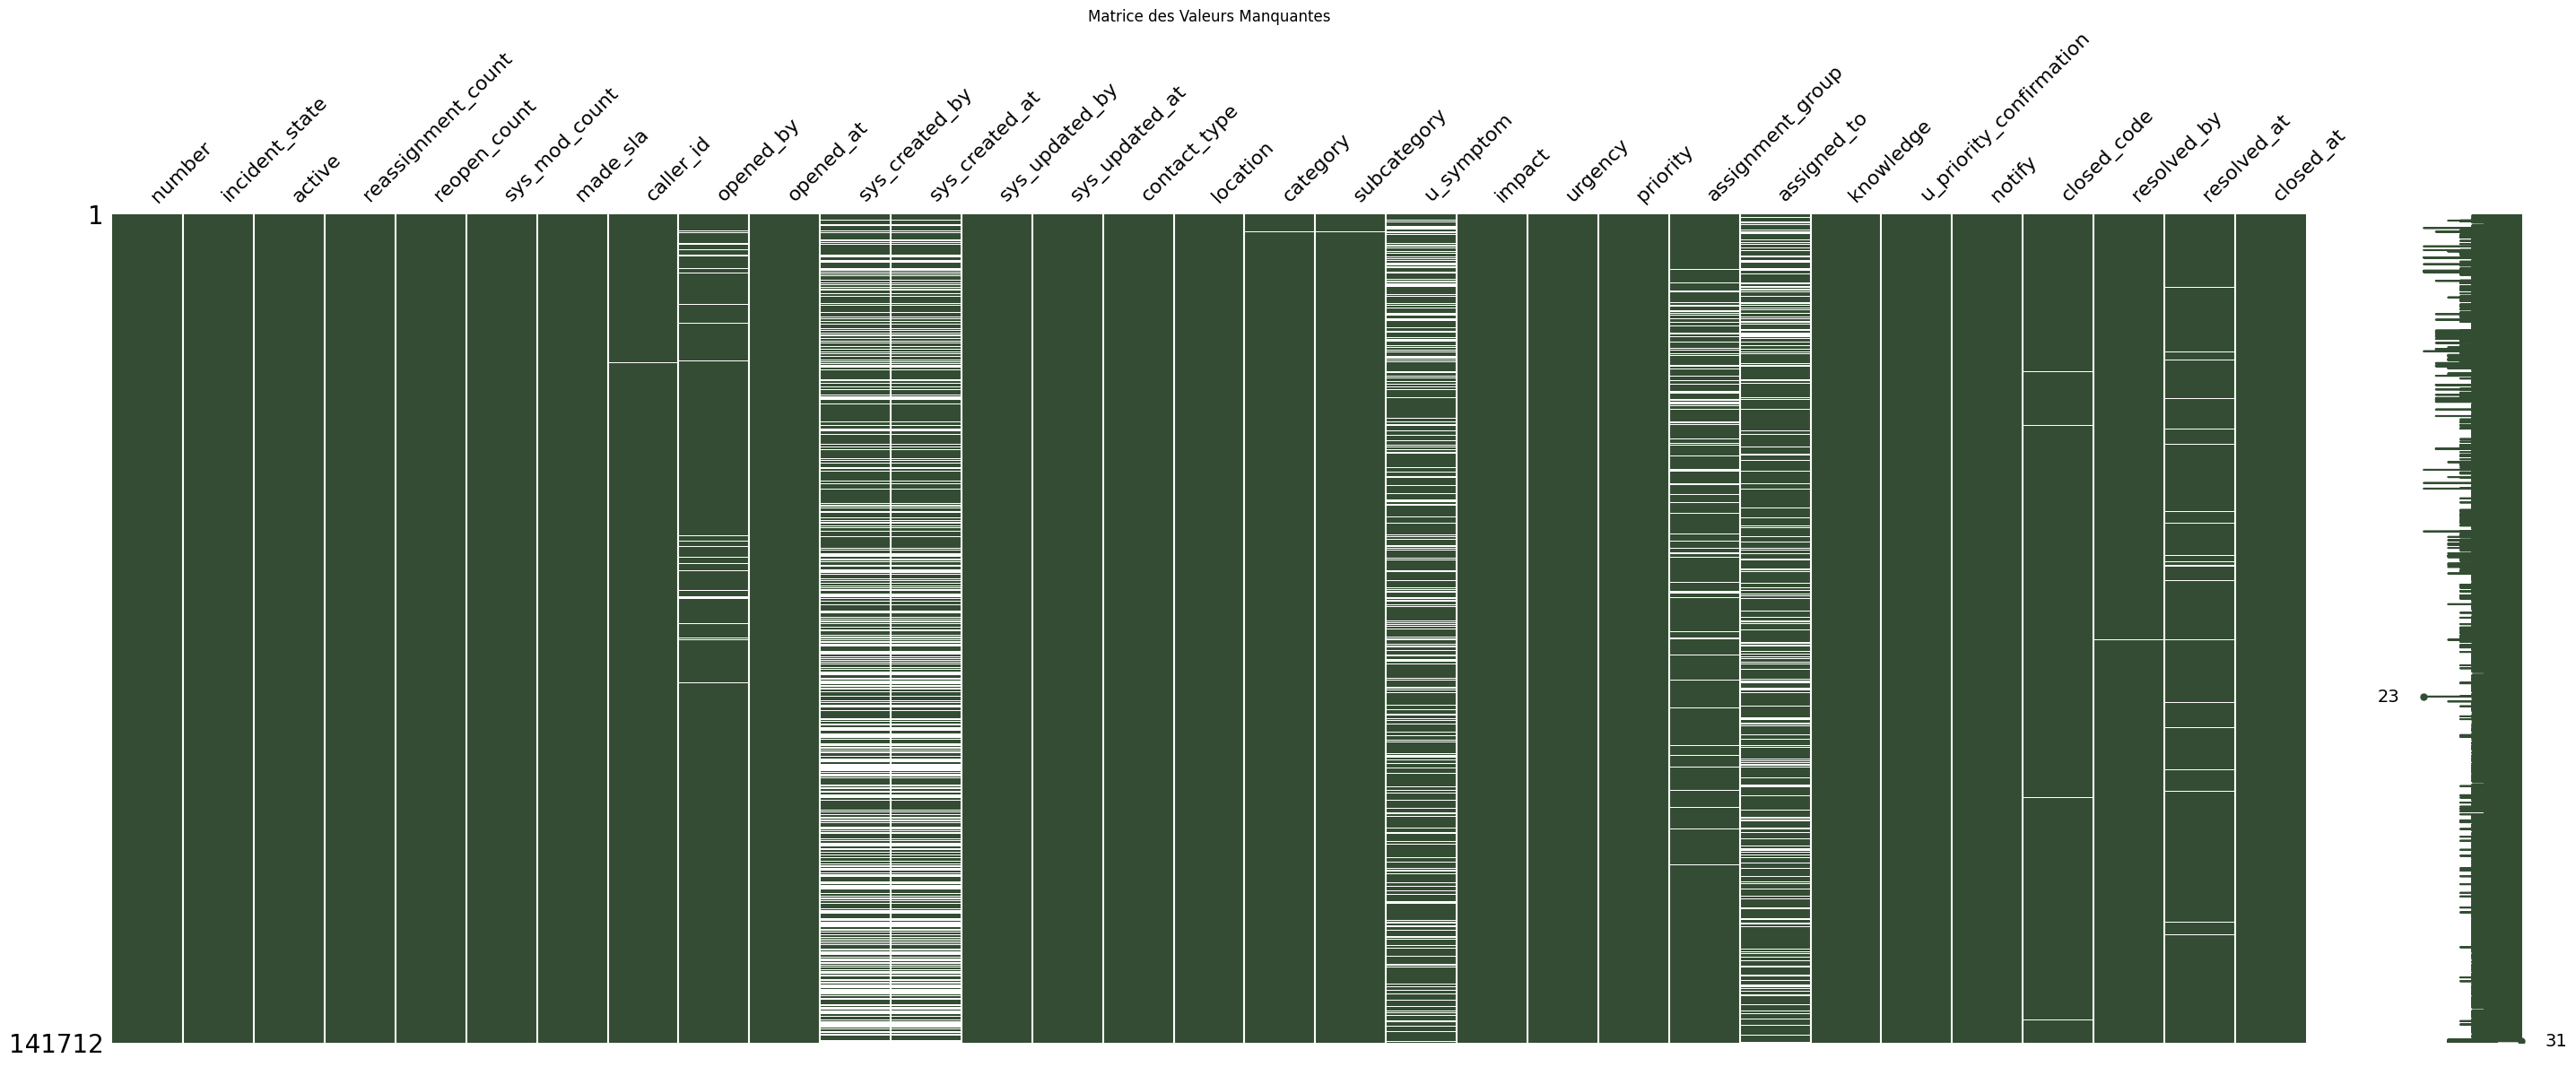

In [ ]:
# Visualisation
import missingno as msno
import matplotlib.pyplot as plt
msno.matrix(df, color=(0.2, 0.3, 0.2),figsize=(35, 12)) #, fontsize=30
plt.title('Matrice des Valeurs Manquantes')
plt.show()

# Litle Test pour les NA

## 1. Identifier les patterns de données manquantes
Chaque ligne est codée selon le pattern de présence/absence des valeurs.

In [ ]:
# Créer une variable "mask" indiquant le pattern de données manquantes
patterns = df.isnull().astype(int)

# Concaténer avec les données
df_patterns = pd.concat([df, patterns], axis=1)
df_patterns

,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,...,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,closed_code,resolved_by,resolved_at,closed_at
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,...,0,0,1,0,0,0,0,0,0,0
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,...,0,0,1,0,0,0,0,0,0,0
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,...,0,0,1,0,0,0,0,0,0,0
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,...,0,0,1,0,0,0,0,0,0,0
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,2016-02-29 04:40:00,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141707,INC0120835,Closed,False,1,0,4,True,Caller 116,Opened by 12,2017-02-16 09:09:00,...,0,0,0,0,0,0,0,0,0,0
141708,INC0121064,Active,True,0,0,0,True,Caller 116,Opened by 12,2017-02-16 14:17:00,...,0,0,0,0,0,0,0,0,0,0
141709,INC0121064,Active,True,1,0,1,True,Caller 116,Opened by 12,2017-02-16 14:17:00,...,0,0,1,0,0,0,0,0,0,0
141710,INC0121064,Resolved,True,1,0,2,True,Caller 116,Opened by 12,2017-02-16 14:17:00,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_patterns.columns


Index(['number', 'incident_state', 'active', 'reassignment_count',
       'reopen_count', 'sys_mod_count', 'made_sla', 'caller_id', 'opened_by',
       'opened_at', 'sys_created_by', 'sys_created_at', 'sys_updated_by',
       'sys_updated_at', 'contact_type', 'location', 'category', 'subcategory',
       'u_symptom', 'impact', 'urgency', 'priority', 'assignment_group',
       'assigned_to', 'knowledge', 'u_priority_confirmation', 'notify',
       'closed_code', 'resolved_by', 'resolved_at', 'closed_at', 'number',
       'incident_state', 'active', 'reassignment_count', 'reopen_count',
       'sys_mod_count', 'made_sla', 'caller_id', 'opened_by', 'opened_at',
       'sys_created_by', 'sys_created_at', 'sys_updated_by', 'sys_updated_at',
       'contact_type', 'location', 'category', 'subcategory', 'u_symptom',
       'impact', 'urgency', 'priority', 'assignment_group', 'assigned_to',
       'knowledge', 'u_priority_confirmation', 'notify', 'closed_code',
       'resolved_by', 'resolved_

## 2. Implémentation du test de Little
Le test de Little repose sur une statistique du khi² (chi-square).
Voici une implémentation simplifiée disponible dans certains notebooks :

In [ ]:
# Analyse des valeurs manquantes
print("   VALEURS MANQUANTES   ")
print("=" * 50)
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df))*100
missing_df = pd.DataFrame({
    'Valeurs_manquantes': missing_data,
    'Pourcentage': missing_percent})
print("Valeurs manquantes par colonne:")
print(missing_df[missing_df['Valeurs_manquantes'] > 0]
      .sort_values('Pourcentage', ascending=False))


   VALEURS MANQUANTES   
Valeurs manquantes par colonne:
                  Valeurs_manquantes  Pourcentage
sys_created_by                 53076    37.453427
sys_created_at                 53076    37.453427
u_symptom                      32964    23.261262
assigned_to                    27496    19.402732
assignment_group               14213    10.029496
opened_by                       4835     3.411849
resolved_at                     3141     2.216467
closed_code                      714     0.503839
resolved_by                      226     0.159478
subcategory                      111     0.078328
category                          78     0.055041
location                          76     0.053630
caller_id                         29     0.020464


In [ ]:
# --- Préparation pour le Test de Little ---
# Le test de Little nécessite des colonnes numériques. Encodez les catégorielles si nécessaire.

# Identifiez les colonnes numériques et catégorielles
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Colonnes numériques:", numeric_cols)
print("Colonnes catégorielles:", categorical_cols)


Colonnes numériques: Index(['reassignment_count', 'reopen_count', 'sys_mod_count'], dtype='object')
Colonnes catégorielles: ['number', 'incident_state', 'caller_id', 'opened_by', 'sys_created_by', 'sys_updated_by', 'contact_type', 'location', 'category', 'subcategory', 'u_symptom', 'impact', 'urgency', 'priority', 'assignment_group', 'assigned_to', 'notify', 'closed_code', 'resolved_by']


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

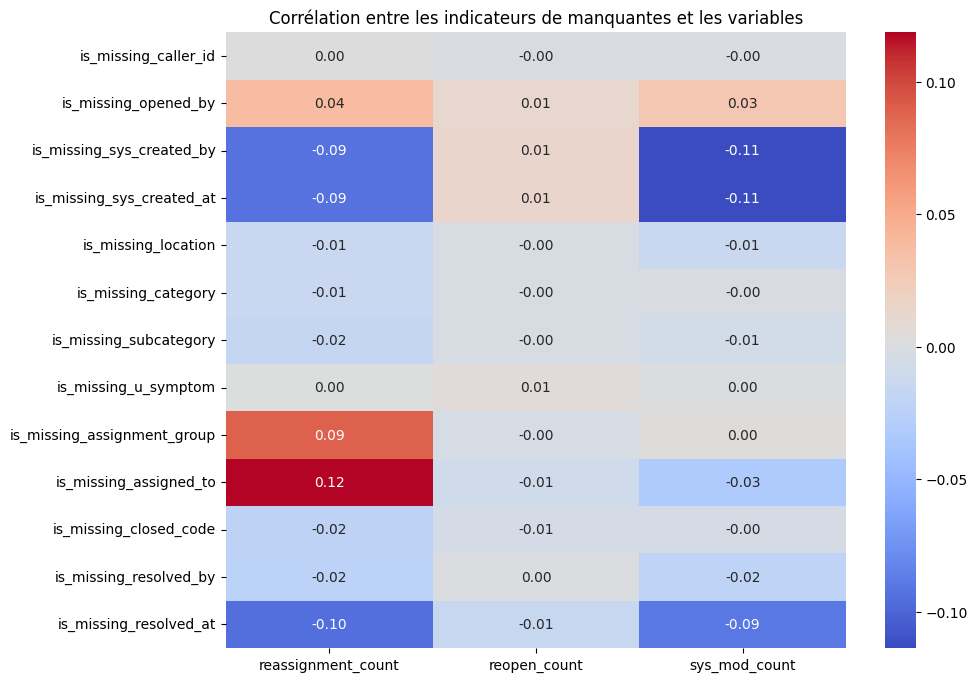

In [ ]:
missing_flags_df = df.isnull().astype(int)
missing_flags_df.columns = [f'is_missing_{col}' for col in df.columns]

# Exclure les colonnes sans manquantes
cols_to_correlate = [col for col in missing_flags_df.columns if missing_flags_df[col].sum() > 0]
missing_flags_df = missing_flags_df[cols_to_correlate]

df_corr = pd.concat([df.select_dtypes(include=np.number), missing_flags_df], axis=1)
corr_matrix = df_corr.corr()

# Filtrer les corrélations pertinentes
relevant_corr = corr_matrix.loc[cols_to_correlate, ~corr_matrix.columns.str.startswith('is_missing_')]

plt.figure(figsize=(10, 8))
sns.heatmap(relevant_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Corrélation entre les indicateurs de manquantes et les variables")
plt.show()

In [ ]:
df.resolved_at.value_counts()

,count
resolved_at,
2016-06-03 16:29:00,93
2016-06-03 16:28:00,85
2016-06-03 16:27:00,83
2016-06-03 16:31:00,59
2016-05-12 23:51:00,58
...,...
2016-03-15 10:04:00,2
2016-03-14 16:31:00,2
2016-03-14 17:05:00,2


In [ ]:
df.head(45)

,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,...,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,closed_code,resolved_by,resolved_at,closed_at
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,...,3 - Moderate,Group 56,NaN,True,False,Do Not Notify,code 5,Resolved by 149,2016-02-29 11:29:00,2016-03-05 12:00:00
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,...,3 - Moderate,Group 56,NaN,True,False,Do Not Notify,code 5,Resolved by 149,2016-02-29 11:29:00,2016-03-05 12:00:00
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,...,3 - Moderate,Group 56,NaN,True,False,Do Not Notify,code 5,Resolved by 149,2016-02-29 11:29:00,2016-03-05 12:00:00
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,...,3 - Moderate,Group 56,NaN,True,False,Do Not Notify,code 5,Resolved by 149,2016-02-29 11:29:00,2016-03-05 12:00:00
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,2016-02-29 04:40:00,...,3 - Moderate,Group 70,Resolver 89,True,False,Do Not Notify,code 5,Resolved by 81,2016-03-01 09:52:00,2016-03-06 10:00:00
5,INC0000047,Active,True,1,0,1,True,Caller 2403,Opened by 397,2016-02-29 04:40:00,...,3 - Moderate,Group 24,Resolver 31,True,False,Do Not Notify,code 5,Resolved by 81,2016-03-01 09:52:00,2016-03-06 10:00:00
6,INC0000047,Active,True,1,0,2,True,Caller 2403,Opened by 397,2016-02-29 04:40:00,...,3 - Moderate,Group 24,Resolver 31,True,False,Do Not Notify,code 5,Resolved by 81,2016-03-01 09:52:00,2016-03-06 10:00:00
7,INC0000047,Active,True,1,0,3,True,Caller 2403,Opened by 397,2016-02-29 04:40:00,...,3 - Moderate,Group 24,Resolver 31,True,False,Do Not Notify,code 5,Resolved by 81,2016-03-01 09:52:00,2016-03-06 10:00:00
8,INC0000047,Active,True,1,0,4,True,Caller 2403,Opened by 397,2016-02-29 04:40:00,...,3 - Moderate,Group 24,Resolver 31,True,False,Do Not Notify,code 5,Resolved by 81,2016-03-01 09:52:00,2016-03-06 10:00:00
9,INC0000047,Active,True,1,0,5,True,Caller 2403,Opened by 397,2016-02-29 04:40:00,...,3 - Moderate,Group 24,Resolver 31,True,False,Do Not Notify,code 5,Resolved by 81,2016-03-01 09:52:00,2016-03-06 10:00:00


In [ ]:
df.tail(35)

,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,...,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,closed_code,resolved_by,resolved_at,closed_at
141677,INC0119390,Active,True,2,0,3,True,Caller 5100,Opened by 490,2017-02-13 10:33:00,...,3 - Moderate,Group 2,NaN,False,False,Do Not Notify,code 6,Resolved by 166,2017-02-14 09:37:00,2017-02-14 12:08:00
141678,INC0119390,Active,True,3,0,4,True,Caller 5100,Opened by 490,2017-02-13 10:33:00,...,3 - Moderate,Group 39,Resolver 36,False,False,Do Not Notify,code 6,Resolved by 166,2017-02-14 09:37:00,2017-02-14 12:08:00
141679,INC0119390,Resolved,True,3,0,5,True,Caller 5100,Opened by 490,2017-02-13 10:33:00,...,3 - Moderate,Group 39,Resolver 36,False,True,Do Not Notify,code 6,Resolved by 166,2017-02-14 09:37:00,2017-02-14 12:08:00
141680,INC0119390,Closed,False,3,0,6,True,Caller 5100,Opened by 490,2017-02-13 10:33:00,...,3 - Moderate,Group 39,Resolver 36,False,True,Do Not Notify,code 6,Resolved by 166,2017-02-14 09:37:00,2017-02-14 12:08:00
141681,INC0119392,New,True,0,0,0,True,Caller 2403,Opened by 508,2017-02-13 10:33:00,...,4 - Low,Group 70,NaN,False,False,Do Not Notify,code 6,NaN,NaT,2017-02-13 10:33:00
141682,INC0119392,Closed,False,0,0,1,True,Caller 2403,Opened by 508,2017-02-13 10:33:00,...,4 - Low,Group 70,NaN,False,False,Do Not Notify,code 6,NaN,NaT,2017-02-13 10:33:00
141683,INC0119457,New,True,0,0,0,True,Caller 2403,Opened by 508,2017-02-13 11:31:00,...,4 - Low,Group 70,NaN,False,False,Do Not Notify,code 6,NaN,NaT,2017-02-13 11:31:00
141684,INC0119457,Closed,False,0,0,1,True,Caller 2403,Opened by 508,2017-02-13 11:31:00,...,4 - Low,Group 70,NaN,False,False,Do Not Notify,code 6,NaN,NaT,2017-02-13 11:31:00
141685,INC0119983,New,True,0,0,0,True,Caller 831,Opened by 508,2017-02-14 11:11:00,...,4 - Low,Group 70,NaN,False,False,Do Not Notify,code 6,NaN,NaT,2017-02-14 11:11:00
141686,INC0119983,Closed,False,0,0,1,True,Caller 831,Opened by 508,2017-02-14 11:11:00,...,4 - Low,Group 70,NaN,False,False,Do Not Notify,code 6,NaN,NaT,2017-02-14 11:11:00


# le litle test n"est pas applicable dans notre cas car les données ne sont pas encodées